In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [83]:
data=pd.read_csv('chip_test.csv')
print (data.head() )

      test1    test2  pass
0  0.051267  0.69956     1
1 -0.092742  0.68494     1
2 -0.213710  0.69225     1
3 -0.375000  0.50219     1
4  0.183760  0.93348     0


In [84]:
mask=data.loc[:,'pass']==1
print(mask)

0       True
1       True
2       True
3       True
4      False
       ...  
113    False
114    False
115    False
116    False
117    False
Name: pass, Length: 118, dtype: bool


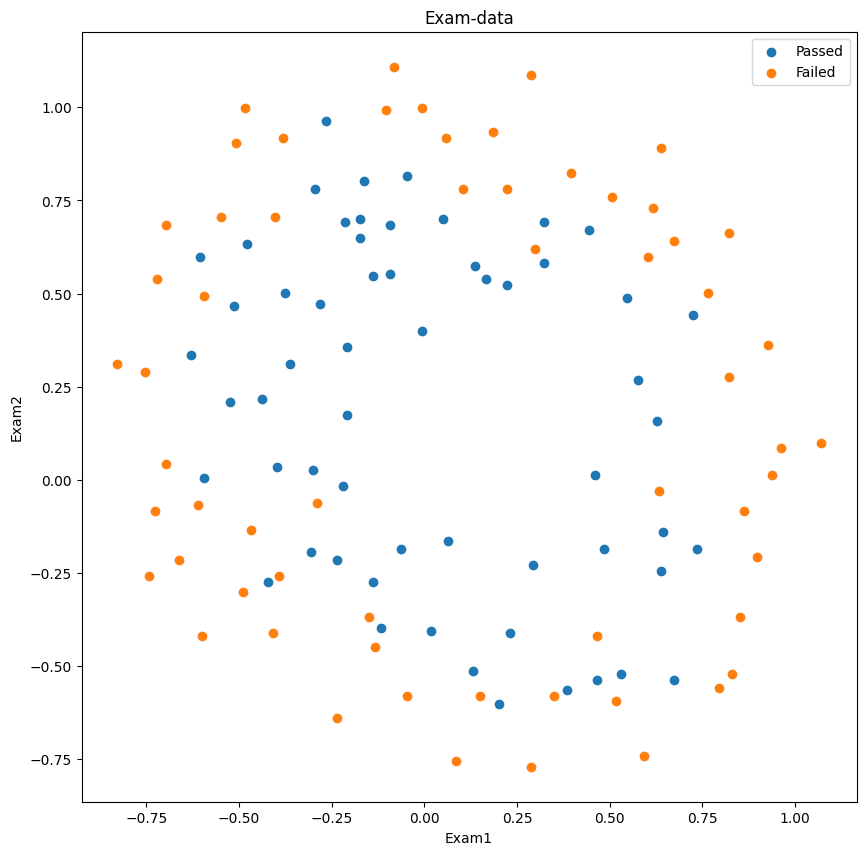

In [85]:
plt2=plt.figure(figsize=(10,10))
passed=plt.scatter(data.loc[:,'test1'][mask],data.loc[:,'test2'][mask])
failed=plt.scatter(data.loc[:,'test1'][~mask],data.loc[:,'test2'][~mask])
plt.title('Exam-data')
plt.xlabel('Exam1')
plt.ylabel('Exam2')
plt.legend((passed,failed),('Passed','Failed'))
plt.show()
plt.show()

In [86]:
X=data.drop(['pass'],axis=1)
y=data.loc[:,'pass']
X1=data.loc[:,'test1']
X2=data.loc[:,'test2']
X1.head()
print(X.shape)

(118, 2)


In [87]:
X1_2=X1*X1
X2_2=X2*X2
X1_X2=X1*X2
X1_new=X1.sort_values()
print(X1,X1_new)

0      0.051267
1     -0.092742
2     -0.213710
3     -0.375000
4      0.183760
         ...   
113   -0.720620
114   -0.593890
115   -0.484450
116   -0.006336
117    0.632650
Name: test1, Length: 118, dtype: float64 112   -0.83007
86    -0.75518
84    -0.74366
111   -0.72638
113   -0.72062
        ...   
70     0.89804
65     0.92684
68     0.93836
67     0.96141
101    1.07090
Name: test1, Length: 118, dtype: float64


In [88]:
X_data_frame={'X1':X1,'X2':X2,'X1_2':X1_2,'X2_2':X2_2,'X1_X2':X1_X2}
X_data_frame=pd.DataFrame(X_data_frame)
print(X_data_frame)

           X1        X2      X1_2      X2_2     X1_X2
0    0.051267  0.699560  0.002628  0.489384  0.035864
1   -0.092742  0.684940  0.008601  0.469143 -0.063523
2   -0.213710  0.692250  0.045672  0.479210 -0.147941
3   -0.375000  0.502190  0.140625  0.252195 -0.188321
4    0.183760  0.933480  0.033768  0.871385  0.171536
..        ...       ...       ...       ...       ...
113 -0.720620  0.538740  0.519293  0.290241 -0.388227
114 -0.593890  0.494880  0.352705  0.244906 -0.293904
115 -0.484450  0.999270  0.234692  0.998541 -0.484096
116 -0.006336  0.999270  0.000040  0.998541 -0.006332
117  0.632650 -0.030612  0.400246  0.000937 -0.019367

[118 rows x 5 columns]


In [89]:
from sklearn.linear_model import LogisticRegression
LR2=LogisticRegression()
LR2.fit(X_data_frame,y)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [90]:
from sklearn.metrics import accuracy_score
predict_2=LR2.predict(X_data_frame)
accuracy2=accuracy_score(y,predict_2)
print(accuracy2)

0.8135593220338984


In [91]:
theta0=LR2.intercept_
theta1,theta2,theta3,theta4,theta5=LR2.coef_[0][0],LR2.coef_[0][1],LR2.coef_[0][2],LR2.coef_[0][3],LR2.coef_[0][4]
print(theta0,theta1,theta2,theta3,theta4,theta5)
#二阶边界函数
a=theta4
b=theta5*X1_new+theta2
c=theta0+theta1*X1_new+theta3*X1_new*X1_new
X2_new_boundary=(-b+np.sqrt(b*b-4*a*c))/(2*a)
print(X2_new_boundary)


[1.19949075] 0.3500680419410171 0.6715136404585058 -2.7816300658355075 -2.390429583411935 -0.9569168535701701
112   NaN
86    NaN
84    NaN
111   NaN
113   NaN
       ..
70    NaN
65    NaN
68    NaN
67    NaN
101   NaN
Name: test1, Length: 118, dtype: float64


C:\Users\25776\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


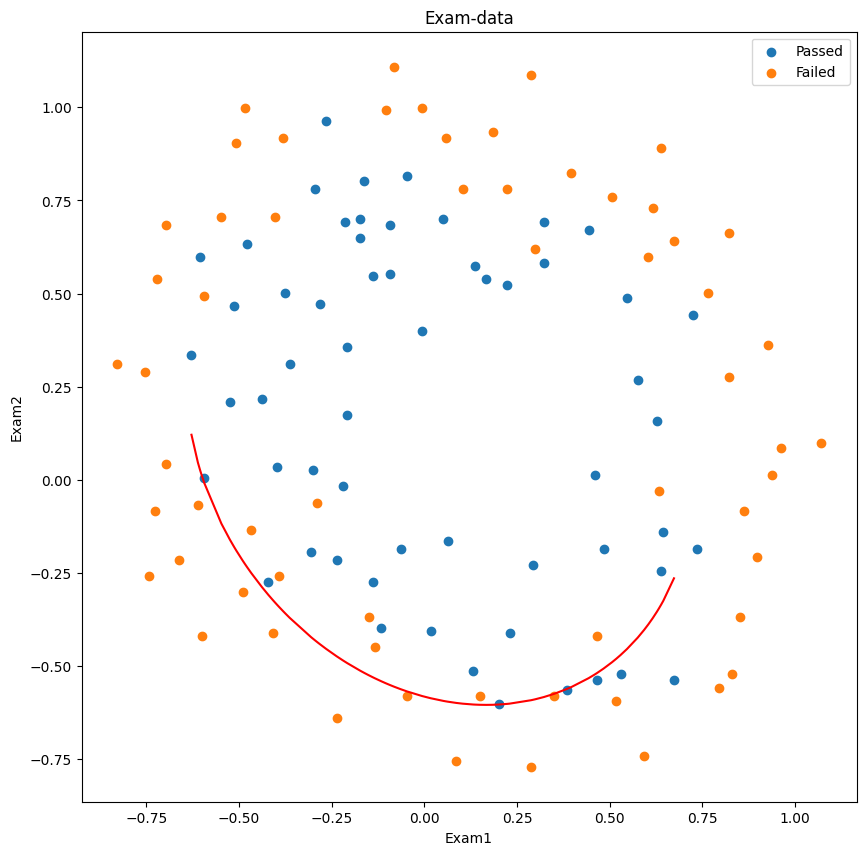

In [92]:
plt2=plt.figure(figsize=(10,10))
passed=plt.scatter(data.loc[:,'test1'][mask],data.loc[:,'test2'][mask])
failed=plt.scatter(data.loc[:,'test1'][~mask],data.loc[:,'test2'][~mask])
plt.title('Exam-data')
plt.xlabel('Exam1')
plt.ylabel('Exam2')
plt.legend((passed,failed),('Passed','Failed'))

#fig4 = plt.figure()
plt.plot(X1_new, X2_new_boundary, 'r')

plt.show()


In [93]:
def f(x):
    a=theta4
    b=theta5*x+theta2
    c=theta0+theta1*x+theta3*x*x
    x1_newboundary=(-b+np.sqrt(b*b-4*a*c))/(2*a)
    x2_newboundary=(-b-np.sqrt(b*b-4*a*c))/(2*a)
    return x1_newboundary,x2_newboundary

In [94]:
X2_new_boundary1=[]
X2_new_boundary2=[]

for x in X1_new:
    X2_new_boundary1.append(f(x)[0])
    X2_new_boundary2.append(f(x)[1])
print(X2_new_boundary1,X2_new_boundary2)

[array([nan]), array([nan]), array([nan]), array([nan]), array([nan]), array([nan]), array([nan]), array([nan]), array([0.12118557]), array([0.046756]), array([0.02694692]), array([0.00869419]), array([-0.00832964]), array([-0.00832964]), array([-0.11719503]), array([-0.16040596]), array([-0.18016739]), array([-0.18965406]), array([-0.21670972]), array([-0.22529994]), array([-0.23369318]), array([-0.24992385]), array([-0.28761169]), array([-0.30846342]), array([-0.32171357]), array([-0.32815515]), array([-0.3344791]), array([-0.34068868]), array([-0.35277682]), array([-0.35866103]), array([-0.37012269]), array([-0.42185219]), array([-0.42655662]), array([-0.43118989]), array([-0.43573725]), array([-0.44020804]), array([-0.45317261]), array([-0.4733505]), array([-0.4733505]), array([-0.48464004]), array([-0.48827191]), array([-0.49183935]), array([-0.49183935]), array([-0.51192772]), array([-0.51192772]), array([-0.51813664]), array([-0.52410902]), array([-0.52985346]), array([-0.529853

C:\Users\25776\AppData\Local\Temp\ipykernel_41092\3157992928.py:5: RuntimeWarning: invalid value encountered in sqrt
  x1_newboundary=(-b+np.sqrt(b*b-4*a*c))/(2*a)
C:\Users\25776\AppData\Local\Temp\ipykernel_41092\3157992928.py:6: RuntimeWarning: invalid value encountered in sqrt
  x2_newboundary=(-b-np.sqrt(b*b-4*a*c))/(2*a)


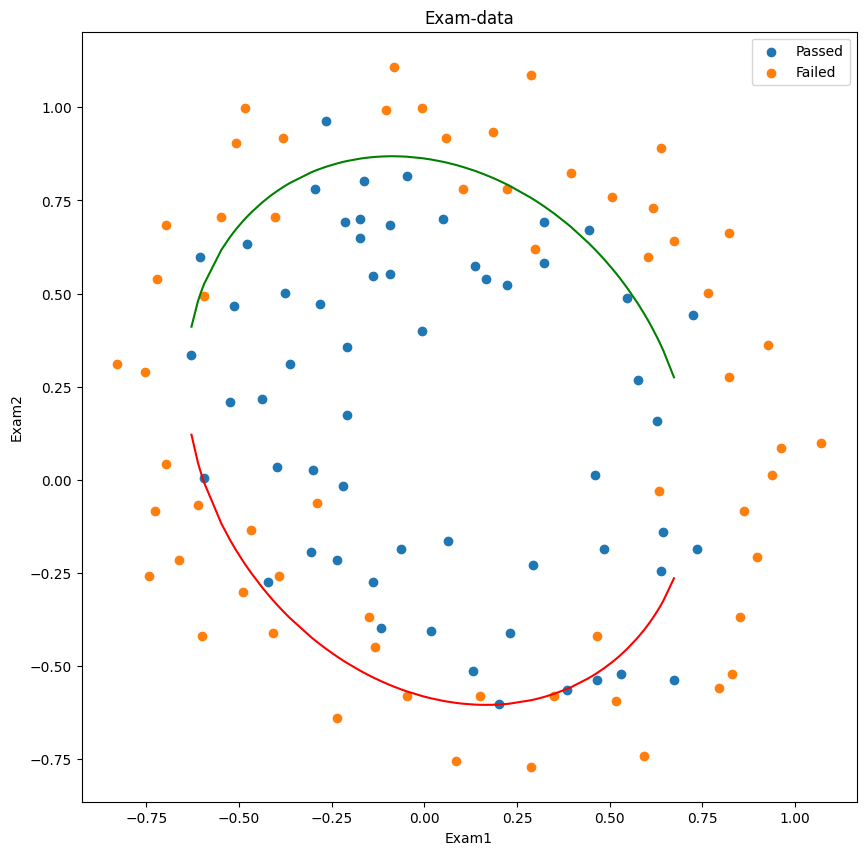

In [95]:
plt3=plt.figure(figsize=(10,10))
passed=plt.scatter(data.loc[:,'test1'][mask],data.loc[:,'test2'][mask])
failed=plt.scatter(data.loc[:,'test1'][~mask],data.loc[:,'test2'][~mask])
plt.title('Exam-data')
plt.xlabel('Exam1')
plt.ylabel('Exam2')
plt.legend((passed,failed),('Passed','Failed'))

#fig4 = plt.figure()
plt.plot(X1_new, X2_new_boundary1, 'r')
plt.plot(X1_new, X2_new_boundary2, 'g')
plt.show()


In [96]:
X1_range=[-0.9+x/10000 for x in range(0,30000)]
X1_range=np.array(X1_range)
X2_new_boundary1=[]
X2_new_boundary2=[]

for x in X1_range:
    X2_new_boundary1.append(f(x)[0])
    X2_new_boundary2.append(f(x)[1])

C:\Users\25776\AppData\Local\Temp\ipykernel_41092\3157992928.py:5: RuntimeWarning: invalid value encountered in sqrt
  x1_newboundary=(-b+np.sqrt(b*b-4*a*c))/(2*a)
C:\Users\25776\AppData\Local\Temp\ipykernel_41092\3157992928.py:6: RuntimeWarning: invalid value encountered in sqrt
  x2_newboundary=(-b-np.sqrt(b*b-4*a*c))/(2*a)


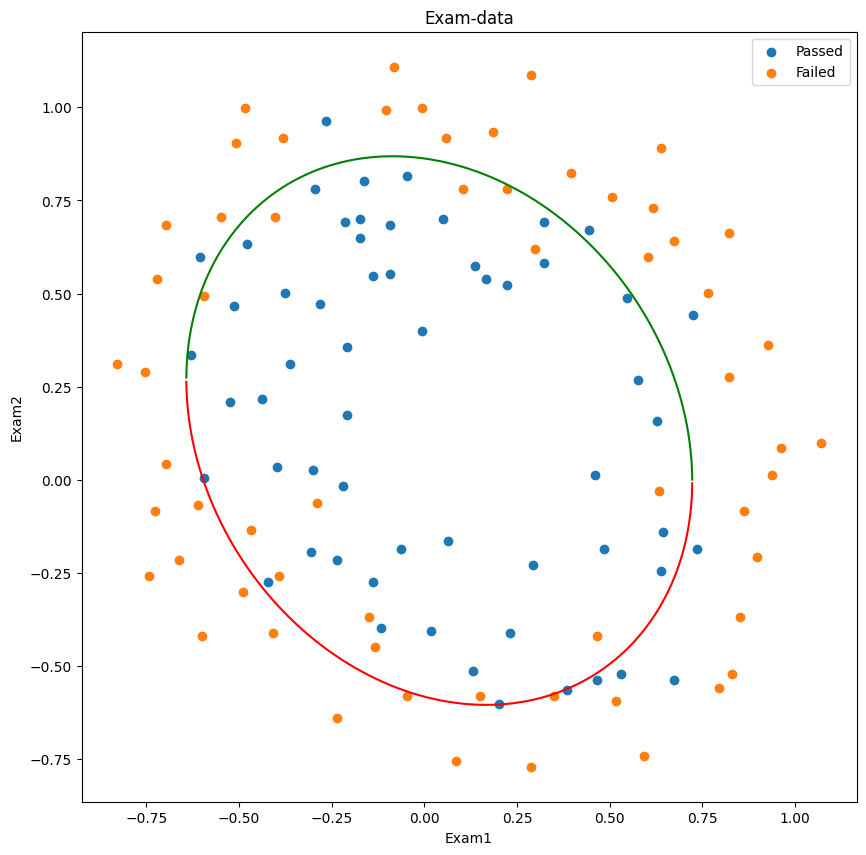

In [99]:
plt4=plt.figure(figsize=(10,10))
passed=plt.scatter(data.loc[:,'test1'][mask],data.loc[:,'test2'][mask])
failed=plt.scatter(data.loc[:,'test1'][~mask],data.loc[:,'test2'][~mask])
plt.title('Exam-data')
plt.xlabel('Exam1')
plt.ylabel('Exam2')
plt.legend((passed,failed),('Passed','Failed'))

#fig4 = plt.figure()
plt.plot(X1_range, X2_new_boundary1, 'r')
plt.plot(X1_range, X2_new_boundary2, 'g')
#plt.legend((passed,failed),('Passed','Failed'))

plt.show()
